# Option pricing, part 2: Bangkok against New York

Thailand's SET50 index has its own options market (TFEX), thinly traded and rarely
studied. Black-Scholes assumes returns are bell-shaped; real markets have fatter tails,
and fat tails are what bend the volatility "smile". This notebook compares one year of
SET50 with the S&P 500 over the same days, and asks **what option prices each market's own
history implies**.

> **Data.** Daily SET50 index closes (Sep 2025 - Oct 2026) and S&P 500 closes for the same
> period. These are index prices, not option prices: the smiles below are what each
> market's *history* implies, not what TFEX traders charged. Calibrating to TFEX quotes
> needs S50 option settlement prices by strike and expiry - the next step.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq

sys.path.insert(0, '..')
import figstyle
figstyle.apply()

set50 = pd.read_csv('data/SET 50 Historical Results Price Data (1).csv', thousands=',')
set50['Date'] = pd.to_datetime(set50['Date'], format='%d/%m/%Y')
set50 = set50.sort_values('Date').set_index('Date')['Price']
spx = pd.read_csv('data/spx_daily_same_period.csv', index_col=0, parse_dates=True).squeeze()

returns = {'SET50 (Bangkok)': np.log(set50).diff().dropna(), 'S&P 500 (New York)': np.log(spx).diff().dropna()}
colours = {'SET50 (Bangkok)': figstyle.PALETTE[1], 'S&P 500 (New York)': figstyle.PALETTE[0]}
for name, r in returns.items():
    print(f"{name:20s} {len(r)} days  realised vol {r.std() * np.sqrt(252):.1%}  "
          f"skew {r.skew():+.2f}  excess kurtosis {r.kurt():.1f}")

SET50 (Bangkok)      262 days  realised vol 15.8%  skew -0.76  excess kurtosis 4.9
S&P 500 (New York)   271 days  realised vol 12.6%  skew -0.21  excess kurtosis 1.2


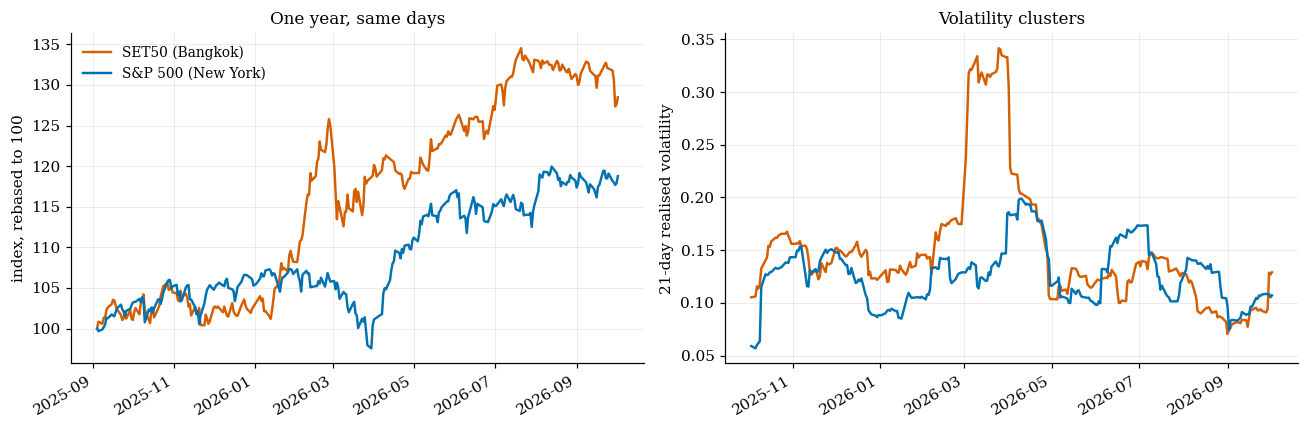

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, series in [('SET50 (Bangkok)', set50), ('S&P 500 (New York)', spx)]:
    axes[0].plot(series.index, series / series.iloc[0] * 100, color=colours[name], label=name)
    r = returns[name]
    axes[1].plot(r.index, r.rolling(21).std() * np.sqrt(252), color=colours[name], label=name)
axes[0].set_ylabel('index, rebased to 100'); axes[0].legend(); axes[0].set_title('One year, same days')
axes[1].set_ylabel('21-day realised volatility'); axes[1].set_title('Volatility clusters')
fig.autofmt_xdate()
fig.tight_layout()
figstyle.save(fig, 'figures/fig5_set50_vs_spx')
plt.show()

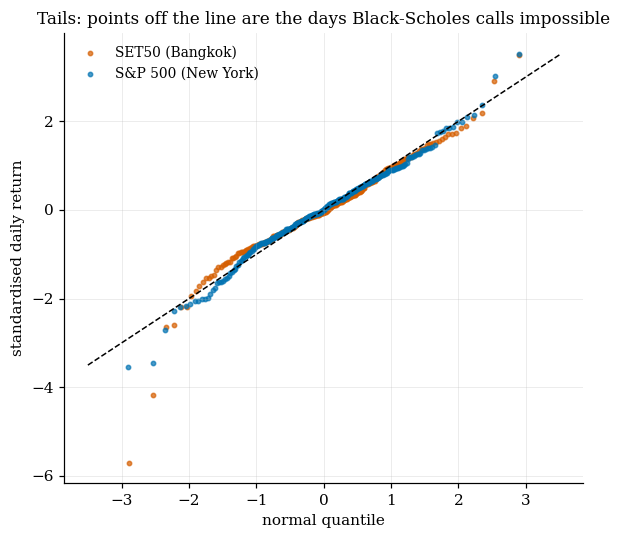

In [3]:
#how far from a bell curve? standardised returns against normal quantiles
fig, ax = plt.subplots(figsize=(5.5, 5))
for name, r in returns.items():
    z = np.sort((r - r.mean()) / r.std())
    q = stats.norm.ppf((np.arange(1, len(z) + 1) - 0.5) / len(z))
    ax.scatter(q, z, s=8, color=colours[name], alpha=0.7, label=name)
ax.plot([-3.5, 3.5], [-3.5, 3.5], 'k--', lw=1)
ax.set_xlabel('normal quantile'); ax.set_ylabel('standardised daily return')
ax.set_title('Tails: points off the line are the days Black-Scholes calls impossible')
ax.legend()
fig.tight_layout()
figstyle.save(fig, 'figures/fig6_tails')
plt.show()

## The skew each market's history implies

Price 3-month options by resampling each index's actual daily returns (a bootstrap, with
the drift removed so the price is fair), then ask: what single Black-Scholes volatility
would give that price? Under a bell curve the answer is the same at every strike - a flat
line. Fat tails make far-from-the-money options dearer, and the line bends into a smile.

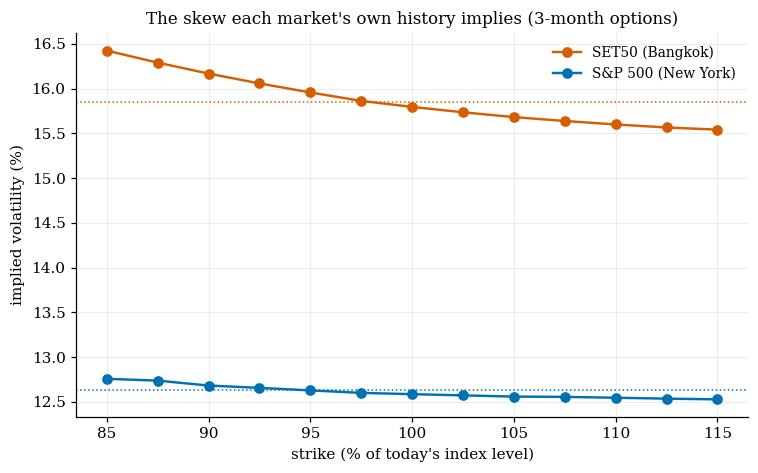

In [4]:
def bs_call(S, K, T, vol):
    d1 = (np.log(S / K) + 0.5 * vol ** 2 * T) / (vol * np.sqrt(T))
    return S * stats.norm.cdf(d1) - K * stats.norm.cdf(d1 - vol * np.sqrt(T))

def implied_vol(price, S, K, T):
    intrinsic = max(S - K, 0)
    if price <= intrinsic + 1e-10:
        return np.nan
    return brentq(lambda v: bs_call(S, K, T, v) - price, 1e-4, 3.0)

def bootstrap_smile(r, days=63, n_paths=200_000, strikes=np.linspace(0.85, 1.15, 13), seed=0):
    rng = np.random.default_rng(seed)
    x = (r - r.mean()).values
    total = rng.choice(x, size=(n_paths, days)).sum(axis=1)
    ST = np.exp(total)
    ST = ST / ST.mean()                                 # fair: E[S_T] = S_0 = 1
    T = days / 252
    prices = [np.mean(np.maximum(ST - K, 0)) for K in strikes]
    return strikes, np.array([implied_vol(p, 1.0, K, T) for p, K in zip(prices, strikes)])

fig, ax = plt.subplots(figsize=(7, 4.4))
for name, r in returns.items():
    k, iv = bootstrap_smile(r)
    ax.plot(k * 100, iv * 100, 'o-', color=colours[name], label=f"{name}")
    ax.axhline(r.std() * np.sqrt(252) * 100, color=colours[name], ls=':', lw=1)
ax.set_xlabel('strike (% of today\'s index level)')
ax.set_ylabel('implied volatility (%)')
ax.set_title('The skew each market\'s own history implies (3-month options)')
ax.legend()
fig.tight_layout()
figstyle.save(fig, 'figures/fig4_set50_skew')
plt.show()

**Bangkok's history implies a steeper skew than New York's - but a gentle one.** SET50 was
more volatile and its falls were bigger than its rises (skew -0.76), so its downside
options "should" cost more than a flat Black-Scholes volatility gives. The fat tails
mostly wash out over three months: 63 independently resampled days add up to something
close to a bell curve. Real smiles are much steeper, because volatility *clusters* - calm
weeks and wild weeks - and a resampling that shuffles days destroys exactly that. Dotted
lines mark each market's plain realised volatility.

Whether TFEX traders price more skew than this history justifies is the question the
option quotes would answer.